In [110]:
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from scipy.stats import randint, uniform
import joblib

### Data Preprocessing

In [111]:
df = pd.read_csv("./datasets/final.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15689,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,77.126264
1,15690,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,77.126264
2,15691,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt

### Identity the features and targets for this model

In [112]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "mem",
                    "extract_duration_problem",
                    "eval_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "alloc_hprod",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["problem", "name", "nvar"]                                                                                                                   # [...]   
first = list(set(group_key + feature_cols_reg + target_cols_reg  + target_col_model))
df = df[first + [c for c in df.columns if c not in first]]    
df                                                                                       # [1, x41 x42 ... x44]

,alloc_grad,stats_elapsed_time,count_plus_minus,count_exponential_function,mem,time_grad,alloc_obj,nvar,total_alloc,problem,neval_grad,tree_depth,alloc_hprod,timed_bytes,extract_duration_problem,eval_duration_problem,tree_length,time_obj,neval_obj,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type
0,4.261110e+07,0.000135,305.0,0.0,1,0.464686,34515160.0,100,77.126264,OptimizationProb...,4.0,9.0,NaN,18576.0,4.309682,1.980544,10404.0,0.376715,4.0,2.0,509.0,arglina,0.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
1,4.261110e+07,0.000151,305.0,0.0,2,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,22120.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
2,4.261110e+07,0.000140,305.0,0.0,3,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,25592.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [113]:
df = df.copy()
df["mem_count"] = df.groupby(["problem", "name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df

,alloc_grad,stats_elapsed_time,count_plus_minus,count_exponential_function,mem,time_grad,alloc_obj,nvar,total_alloc,problem,neval_grad,tree_depth,alloc_hprod,timed_bytes,extract_duration_problem,eval_duration_problem,tree_length,time_obj,neval_obj,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,42611104.0,0.000135,305.0,0.0,1,0.464686,34515160.0,100,77.126264,OptimizationProb...,4.0,9.0,NaN,18576.0,4.309682,1.980544,10404.0,0.376715,4.0,2.0,509.0,arglina,0.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,42611104.0,0.000151,305.0,0.0,2,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,22120.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,42611104.0,0.000140,305.0,0.0,3,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,25592.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [114]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df

,alloc_grad,stats_elapsed_time,count_plus_minus,count_exponential_function,mem,time_grad,alloc_obj,nvar,total_alloc,problem,neval_grad,tree_depth,alloc_hprod,timed_bytes,extract_duration_problem,eval_duration_problem,tree_length,time_obj,neval_obj,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,42611104.0,0.000135,305.0,0.0,1,0.464686,34515160.0,100,77.126264,OptimizationProb...,4.0,9.0,NaN,18576.0,4.309682,1.980544,10404.0,0.376715,4.0,2.0,509.0,arglina,0.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,42611104.0,0.000151,305.0,0.0,2,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,22120.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,42611104.0,0.000140,305.0,0.0,3,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,25592.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [115]:
 # confirm and use the three predicted feature to predict time                                                                                                              #  
X_train = train_df[feature_cols_reg].to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)

### Model selections and hyperparameter tunings of the model

### Best Model: MultiOutputRegressor wrapper with ExtraTreesRegressor (Extremely Randomized Trees)

In [7]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# best_model = MultiOutputRegressor(
#     ExtraTreesRegressor(n_estimators=300, max_depth=10, min_samples_leaf = 5, random_state=123, n_jobs=-1)
#     # TRY random forest 
# )
# best_model.fit(X_train, y_train)
# y_pred = best_model.predict(X_valid)
# print(f"Best model MSE={mean_squared_error(y_valid, y_pred):.4f}  R²={r2_score(y_valid, y_pred):.4f}")

### Random forest 

In [8]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': [None] + list(range(3, 101)),
#     'min_samples_split': randint(2, 100),
#     'min_samples_leaf': randint(1, 50),
#     'max_features': ['sqrt', 'log2'] + list(np.linspace(0.1, 1.0, 19)),
#     'bootstrap': [True, False],
#     'min_impurity_decrease': uniform(0, 0.1),
#     'ccp_alpha': uniform(0, 0.2),
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=50, 
#     cv=10,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
# )

# random_search.fit(X_train, y_train)

# # Results
# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", random_search.best_params_)
# print("Best CV score (neg MSE):", random_search.best_score_)
# print("Actual MSE:", -random_search.best_score_)

# # Save detailed results
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# # Top 20 configurations
# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# # Save to CSV
# results_df.to_csv('rf_randomsearch_comprehensive_results.csv', index=False)
# print(f"\nFull results saved to rf_randomsearch_comprehensive_results.csv")

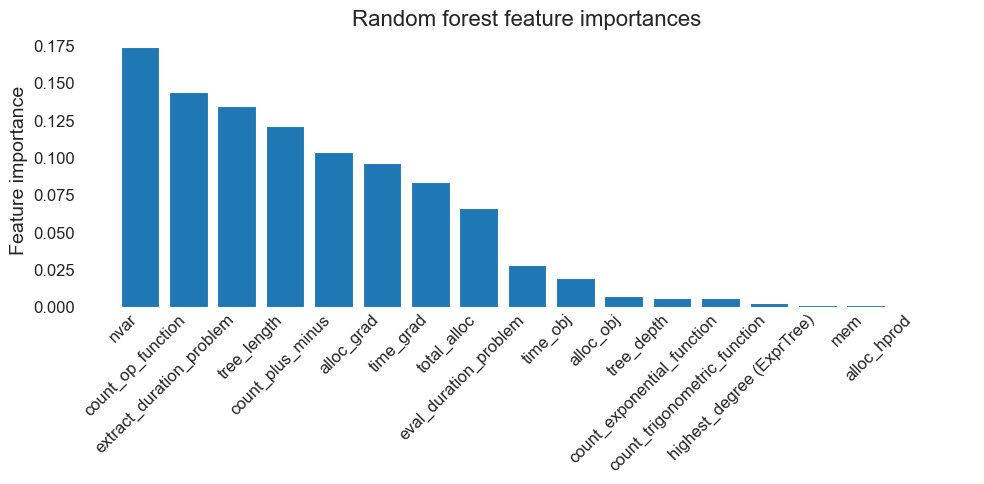

['./model_weights/best_rf_model_reg.pkl']

In [116]:
import numpy as np
import matplotlib.pyplot as plt

best_model = joblib.load('./model_weights/best_rf_model_reg.pkl')
rf_importances = best_model.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

joblib.dump(best_model, './model_weights/best_rf_model_reg.pkl')

In [117]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test) / np.abs(y_test + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error[:, i] < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=2.7922  R²=0.2813

neval_obj:
Relative Error | Under Threshold | Percentage
  <   5%:  2.85%
  <  10%:  10.90%
  <  15%:  23.59%
  <  20%:  31.83%
  <  30%:  53.15%
  <  50%:  92.61%

neval_grad:
Relative Error | Under Threshold | Percentage
  <   5%:  2.80%
  <  10%:  10.46%
  <  15%:  21.88%
  <  20%:  30.95%
  <  30%:  43.59%
  <  50%:  82.00%

timed_bytes:
Relative Error | Under Threshold | Percentage
  <   5%:  48.22%
  <  10%:  85.12%
  <  15%:  92.32%
  <  20%:  97.76%
  <  30%:  99.68%
  <  50%:  100.00%


[]

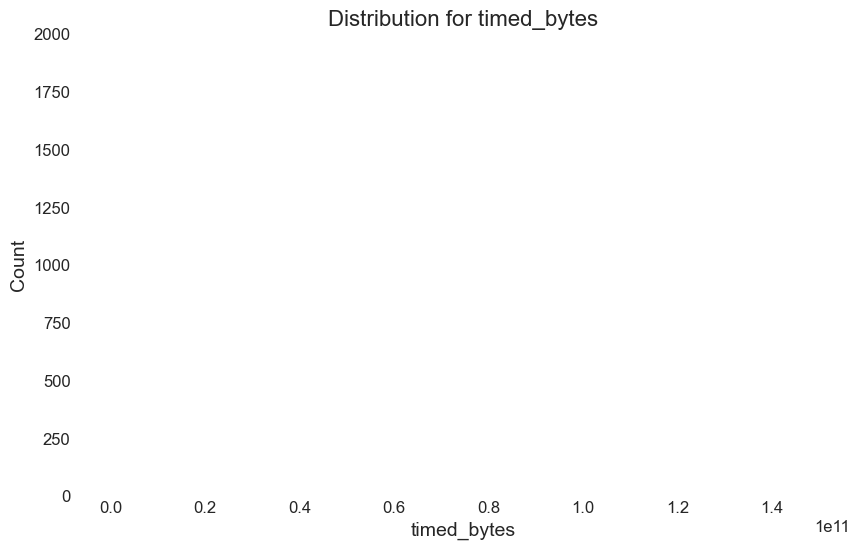

In [161]:
import seaborn as sns
x = df["timed_bytes"]
sns.histplot(x=x)
plt.ylim(0, 2000)
plt.title("Distribution for timed_bytes")
plt.plot()

### Using the predicted value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [11]:
X_train_time = best_model.predict(X_train)
X_test_time = best_model.predict(X_test)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [12]:
time_predictor = RandomForestRegressor()
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.5705226178283116

In [13]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': [None] + list(range(3, 101)),
#     'min_samples_split': randint(2, 100),
#     'min_samples_leaf': randint(1, 50),
#     'max_features': ['sqrt', 'log2'],
#     'bootstrap': [True, False],
#     'min_impurity_decrease': uniform(0, 0.1),
#     'ccp_alpha': uniform(0, 0.2),
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# time_random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=50,
#     cv=5,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
#     error_score = 'raise'
# )

# time_random_search.fit(X_train_time, y_train_time)


In [118]:
time_best_model = joblib.load('./model_weights/best_rf_model_time.pkl')
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model, './model_weights/best_rf_model_time.pkl')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Time prediction accuracy based on predicted values=-0.9372965779342306


['./model_weights/best_rf_model_time.pkl']

In [119]:
pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=7.6798  R²=-0.9373

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  7.61%
  <  10%:  15.76%
  <  15%:  22.78%
  <  20%:  23.98%
  <  30%:  24.12%
  <  50%:  29.22%


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


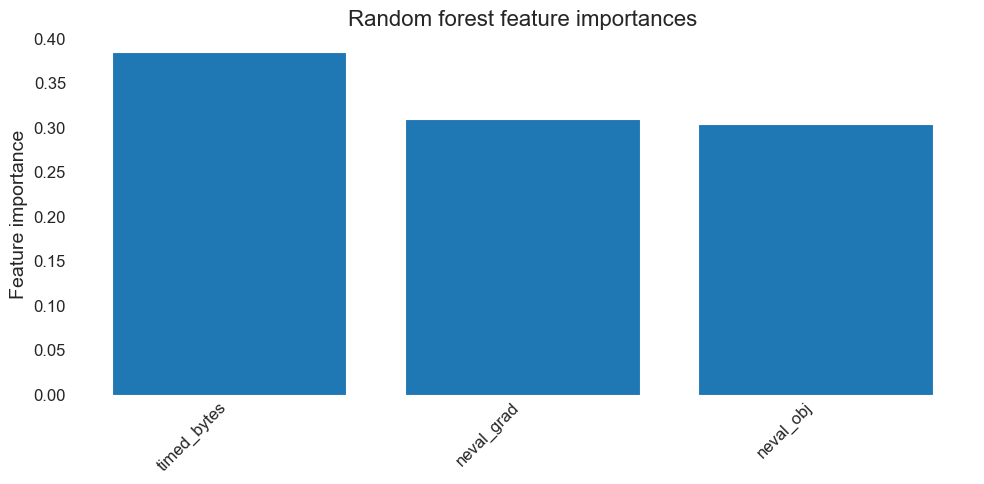

In [120]:
best_model_time = time_best_model
rf_importances = best_model_time.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Using the actual value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [121]:
X_train_time = train_df[target_cols_reg]
X_test_time = test_df[target_cols_reg]
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [122]:
time_predictor = RandomForestRegressor()
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.29680305376628746

In [19]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': [None] + list(range(3, 101)),
#     'min_samples_split': randint(2, 100),
#     'min_samples_leaf': randint(1, 50),
#     'max_features': ['sqrt', 'log2'] + list(np.linspace(0.1, 1.0, 19)),
#     'bootstrap': [True, False],
#     'min_impurity_decrease': uniform(0, 0.1),
#     'ccp_alpha': uniform(0, 0.2),
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# time_random_search_raw = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=50,
#     cv=3,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True
# )

# time_random_search_raw.fit(X_train_time, y_train_time)

In [123]:
time_best_model_raw = joblib.load('./model_weights/best_rf_model_time_raw.pkl')
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_rf_model_time_raw.pkl')

Time prediction accuracy based on predicted values=0.7333587345908344


['./model_weights/best_rf_model_time_raw.pkl']

In [124]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=1.0570  R²=0.7334

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  1.15%
  <  10%:  2.83%
  <  15%:  9.27%
  <  20%:  12.41%
  <  30%:  26.61%
  <  50%:  36.49%


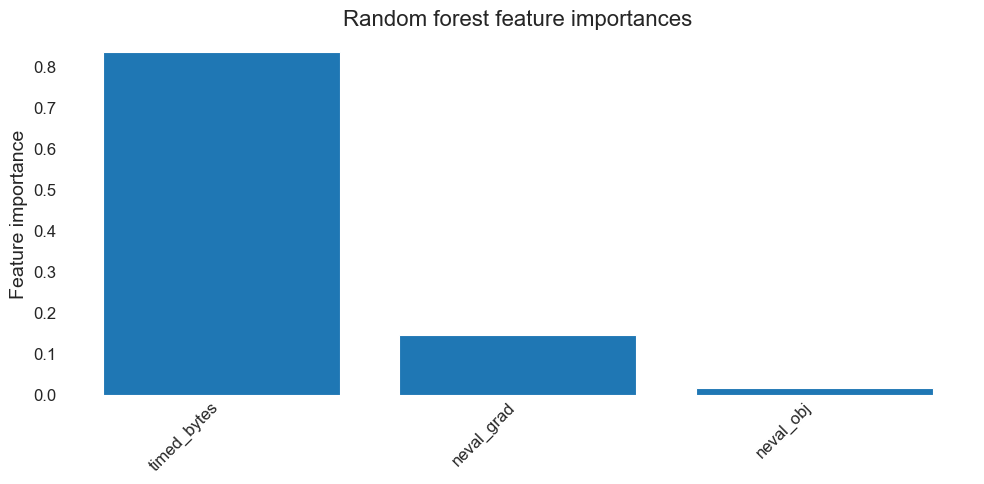

In [125]:
best_model_time_raw = time_best_model_raw
rf_importances = best_model_time_raw.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Using linear regression model to predict time based on the ["timed_bytes", "neval_grad", "neval_obj"]

In [126]:
lr = LinearRegression()
lr_model = lr.fit(X_train_time, y_train_time)
accuracy = lr.score(X_test_time, y_test_time)
print(f"Default Linear Regression Model Test Accuracy={accuracy}")

Default Linear Regression Model Test Accuracy=-0.014087862223982617


In [127]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'alpha': np.logspace(-3, 3, 100),
    'positive': [True, False],
    'fit_intercept': [True, False]
}

ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

ridge_search.fit(X_train_time, y_train_time)
print(f"Best params: {ridge_search.best_params_}")
print(f"Best CV R²: {ridge_search.best_score_}")
print(f"Test R²: {ridge_search.score(X_test_time, y_test_time)}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'positive': True, 'fit_intercept': True, 'alpha': 17.47528400007683}
Best CV R²: -10574.666717485827
Test R²: -0.016707324688332026


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=3.60939e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.89163e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.92716e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.92646e-17): result may not be acc

### Now let's use stats_ellapsed_time to predict the corresponding best mem value

In [128]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [129]:
test_df

,alloc_grad,stats_elapsed_time,count_plus_minus,count_exponential_function,mem,time_grad,alloc_obj,nvar,total_alloc,problem,neval_grad,tree_depth,alloc_hprod,timed_bytes,extract_duration_problem,eval_duration_problem,tree_length,time_obj,neval_obj,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,52547568.0,0.000229,400.0,0.0,1,1.029701,45676488.0,100,98.224056,OptimizationProb...,8.0,8.0,NaN,20176.0,6.859471,3.275820,40200.0,0.288629,56.0,2.0,20600.0,arglinb,0.0,4502,2.0,2.481297e+01,0.290308,0.011412,0.055305,first_order,0.000254,0.000000,0.309318,2.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,52547568.0,0.000294,400.0,0.0,2,1.029701,45676488.0,100,98.224056,OptimizationProb...,4.0,8.0,NaN,23720.0,6.859471,3.275820,40200.0,0.288629,28.0,2.0,20600.0,arglinb,0.0,4503,2.0,2.481297e+01,0.290308,0.011532,0.055305,first_order,0.000376,0.000000,0.309318,2.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,52547568.0,0.000294,400.0,0.0,3,1.029701,45676488.0,100,98.224056,OptimizationProb...,4.0,8.0,NaN,27192.0,6.859471,3.275820,40200.0,0.288629,28.0,2.0,20600.0,arglinb,0.0,4504,2.0,2.481297e+01,0.290308,0.011493,0.055305,first_order,0.000387,0.000000,0.309318,2.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0

In [ ]:
X_all_time = all_df[target_cols_reg]
y_pred = best_model_time_raw.predict(X_all_time)
y_pred_df = pd.DataFrame(y_pred, columns=["predicted_time"])
y_pred_df
all_df_new = all_df.join(y_pred_df, how="inner").reset_index(drop=True)
all_df_new.head(20)


,alloc_grad,stats_elapsed_time,count_plus_minus,count_exponential_function,mem,time_grad,alloc_obj,nvar,total_alloc,problem,neval_grad,tree_depth,alloc_hprod,timed_bytes,extract_duration_problem,eval_duration_problem,tree_length,time_obj,neval_obj,highest_degree (ExprTree),count_op_function,name,count_trigonometric_function,index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count,predicted_time
0,42611104.0,0.000135,305.0,0.0,1,0.464686,34515160.0,100,77.126264,OptimizationProb...,4.0,9.0,NaN,18576.0,4.309682,1.980544,10404.0,0.376715,4.0,2.0,509.0,arglina,0.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100,0.107250
1,42611104.0,0.000151,305.0,0.0,2,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,22120.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100,0.107250
2,42611104.0,0.000140,305.0,0.0,3,0.464686,34515160.0,100,77.126264,OptimizationProb...,2.0,9.0,NaN,25592.0,4.309682,1.980544,10404.0,0.376715,2.0,2.0,509.0,arglina,0.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt..

In [131]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [132]:
group_cols = ["problem", "name", "nvar"]
best_idx = all_df_new.groupby(group_cols)["predicted_time"].idxmin()
best_mem_map = all_df_new.loc[best_idx].set_index(group_cols)["mem"]
all_df_new["best_predicted_mem"] = all_df_new.set_index(group_cols).index.map(best_mem_map)
all_df_new["best_predicted_mem"].describe()

count    20100.000000
mean         2.716418
std          7.538097
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         98.000000
Name: best_predicted_mem, dtype: float64

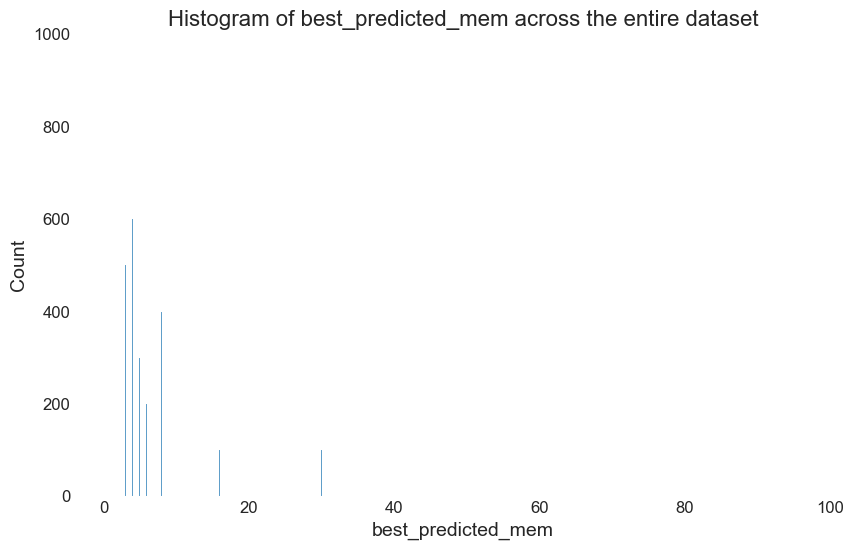

In [154]:
# %pip install seaborn
import seaborn as sns
x = all_df_new["best_predicted_mem"]
sns.histplot(x=x)
plt.ylim(0, 1000)
plt.title("Histogram of best_predicted_mem across the entire dataset")
plt.show()

In [145]:
x.describe()

count    20100.000000
mean         2.716418
std          7.538097
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         98.000000
Name: best_predicted_mem, dtype: float64

In [134]:
all_df_new["best_observed_mem"] = df["best_observed_mem"]

Global mem prediction difference=32.024875621890544


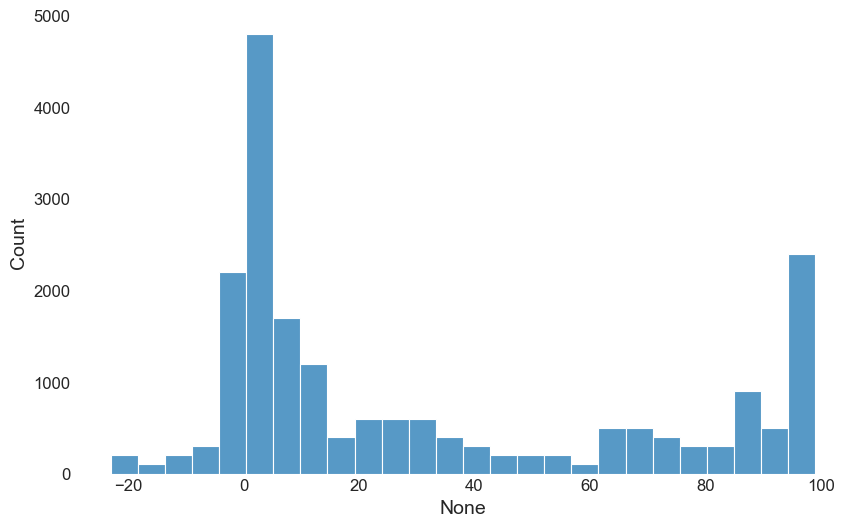

In [ ]:
mem_differences = all_df_new["best_observed_mem"] - all_df_new["best_predicted_mem"]
differences = np.mean(mem_differences)
print(f"Global mem prediction difference={differences}")
x = mem_differences
sns.histplot(x=x)
plt.show()

In [153]:
# Absolute time difference (regret)
time_differences = abs(all_df_new["stats_elapsed_time"] - all_df_new["predicted_time"])
mean_absolute_regret = np.mean(time_differences)
print(f"Mean absolute time regret: {mean_absolute_regret}")
print(list(time_differences))

Mean absolute time regret: 134.1281580860436
[0.10711540297194931, 0.10709942892714931, 0.10711015776320931, 0.10709942892714931, 0.10711134985610431, 0.10711134985610431, 0.10700835302993231, 0.10700835302993231, 0.10699547842666131, 0.10700835302993231, 0.10700334623977131, 0.1070073993556163, 0.1069914253108163, 0.10667623594924432, 0.1068533809535163, 0.10700048521682232, 0.1070073993556163, 0.10699428633376531, 0.10700835302993231, 0.10700835302993231, 0.10699643210097731, 0.1070073993556163, 0.10700429991408832, 0.10700429991408832, 0.1069952400080823, 0.1070073993556163, 0.10700716093703731, 0.10700549200698331, 0.10699547842666131, 0.1070073993556163, 0.1070073993556163, 0.1070073993556163, 0.10698331907912731, 0.1070143134944103, 0.10702718809768132, 0.1070364864222663, 0.10701717451735931, 0.10703529432937131, 0.10703744009658331, 0.1070312412135263, 0.10704125479384831, 0.10703434065505431, 0.10703934744521632, 0.10704053953811131, 0.1070333869807383, 0.10704053953811131, 0.

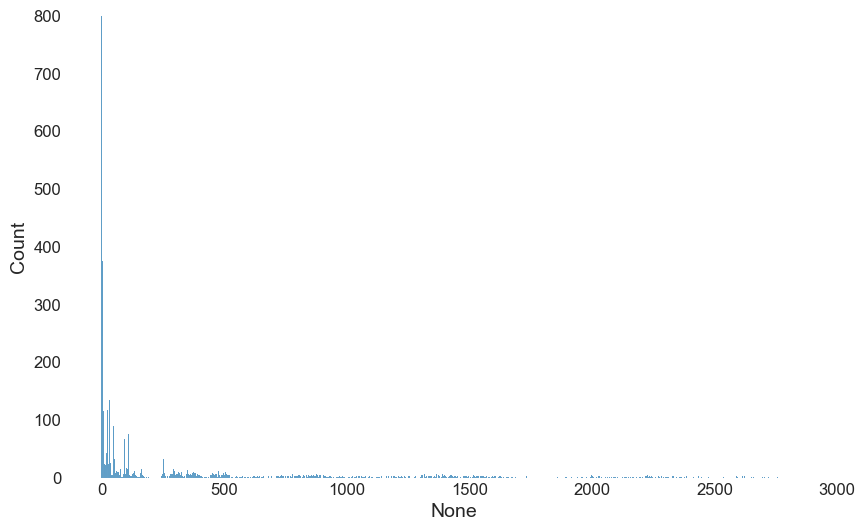

0        0.107115
1        0.107099
2        0.107110
3        0.107099
4        0.107111
           ...   
20095    6.044373
20096    6.044126
20097    6.044241
20098    6.044330
20099    6.944350
Length: 20100, dtype: float64

In [ ]:
x = time_differences
sns.histplot(x=x)
plt.title()
plt.ylim(0, 800)
plt.show()
x

True distribution of best mem:
best_observed_mem
1      0.119403
2      0.034826
3      0.054726
4      0.069652
5      0.029851
         ...   
96     0.019900
97     0.024876
98     0.004975
99     0.039801
100    0.034826
Name: proportion, Length: 61, dtype: float64


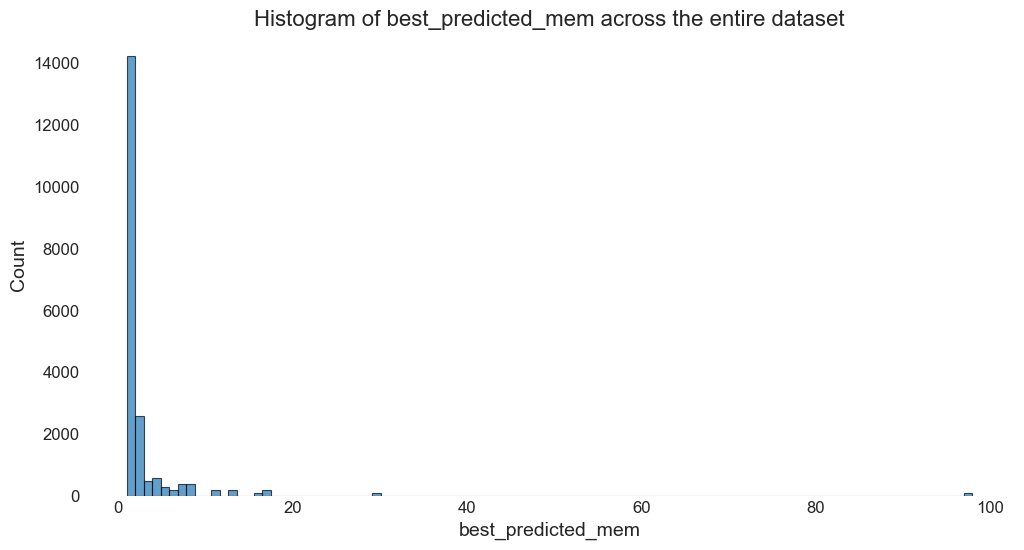

In [138]:
# Distribution of actual best mems
print("True distribution of best mem:")
print(all_df_new['best_observed_mem'].value_counts(normalize=True).sort_index())

# Predicted distribution (should match the observed pattern above)
plt.figure(figsize=(12, 6))
plt.hist(all_df_new['best_predicted_mem'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Histogram of best_predicted_mem across the entire dataset')
plt.xlabel('best_predicted_mem')
plt.ylabel('Count')
plt.show()

### Mem evaluation metrics

In [139]:
# How far off is the predicted mem from actual (in mem units)
mem_absolute_error = abs(all_df_new['best_predicted_mem'] - all_df_new['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 33.15
Median Absolute Mem Error: 13.00


In [140]:
# How close are the predictions? 1.0 = perfect, 0.0 = very far
mem_match_ratio = np.minimum(all_df_new['best_predicted_mem'], 
                              all_df_new['best_observed_mem']) / \
                  np.maximum(all_df_new['best_predicted_mem'], 
                              all_df_new['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x (e.g., pred=50, actual=100)
# 0.1 = off by 10x (e.g., pred=10, actual=100)

Mean Mem Match Ratio: 0.215
